In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/aptos2019-blindness-detection/sample_submission.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train.csv
/kaggle/input/competitions/aptos2019-blindness-detection/test.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ef476be214d4.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/6dcde47060f9.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ec363f48867b.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/17f6c7072f61.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/b49b2fac2514.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/af6166d57f13.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/8d13c46e7d75.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/c3b15bf9b4bc.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/be68322c7223.png
/kagg

In [3]:
import os, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch

BASE = '/kaggle/input/competitions/aptos2019-blindness-detection'
df = pd.read_csv(f'{BASE}/train.csv')

print(df.shape)
print(df['diagnosis'].value_counts().sort_index())
print('GPU available:', torch.cuda.is_available())

(3662, 2)
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64
GPU available: True


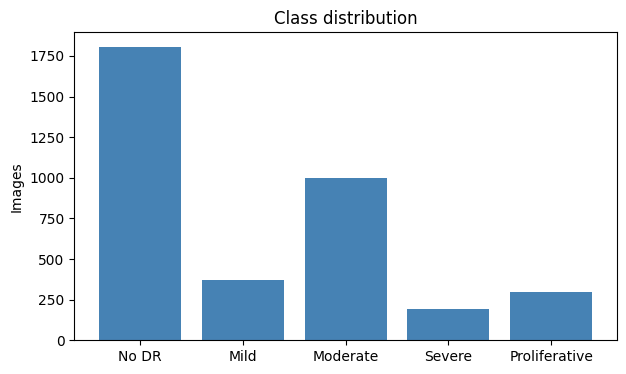

In [4]:
labels = {0:'No DR', 1:'Mild', 2:'Moderate', 3:'Severe', 4:'Proliferative'}
counts = df['diagnosis'].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.bar([labels[i] for i in counts.index], counts.values, color='steelblue')
plt.title('Class distribution'); plt.ylabel('Images')
plt.show()

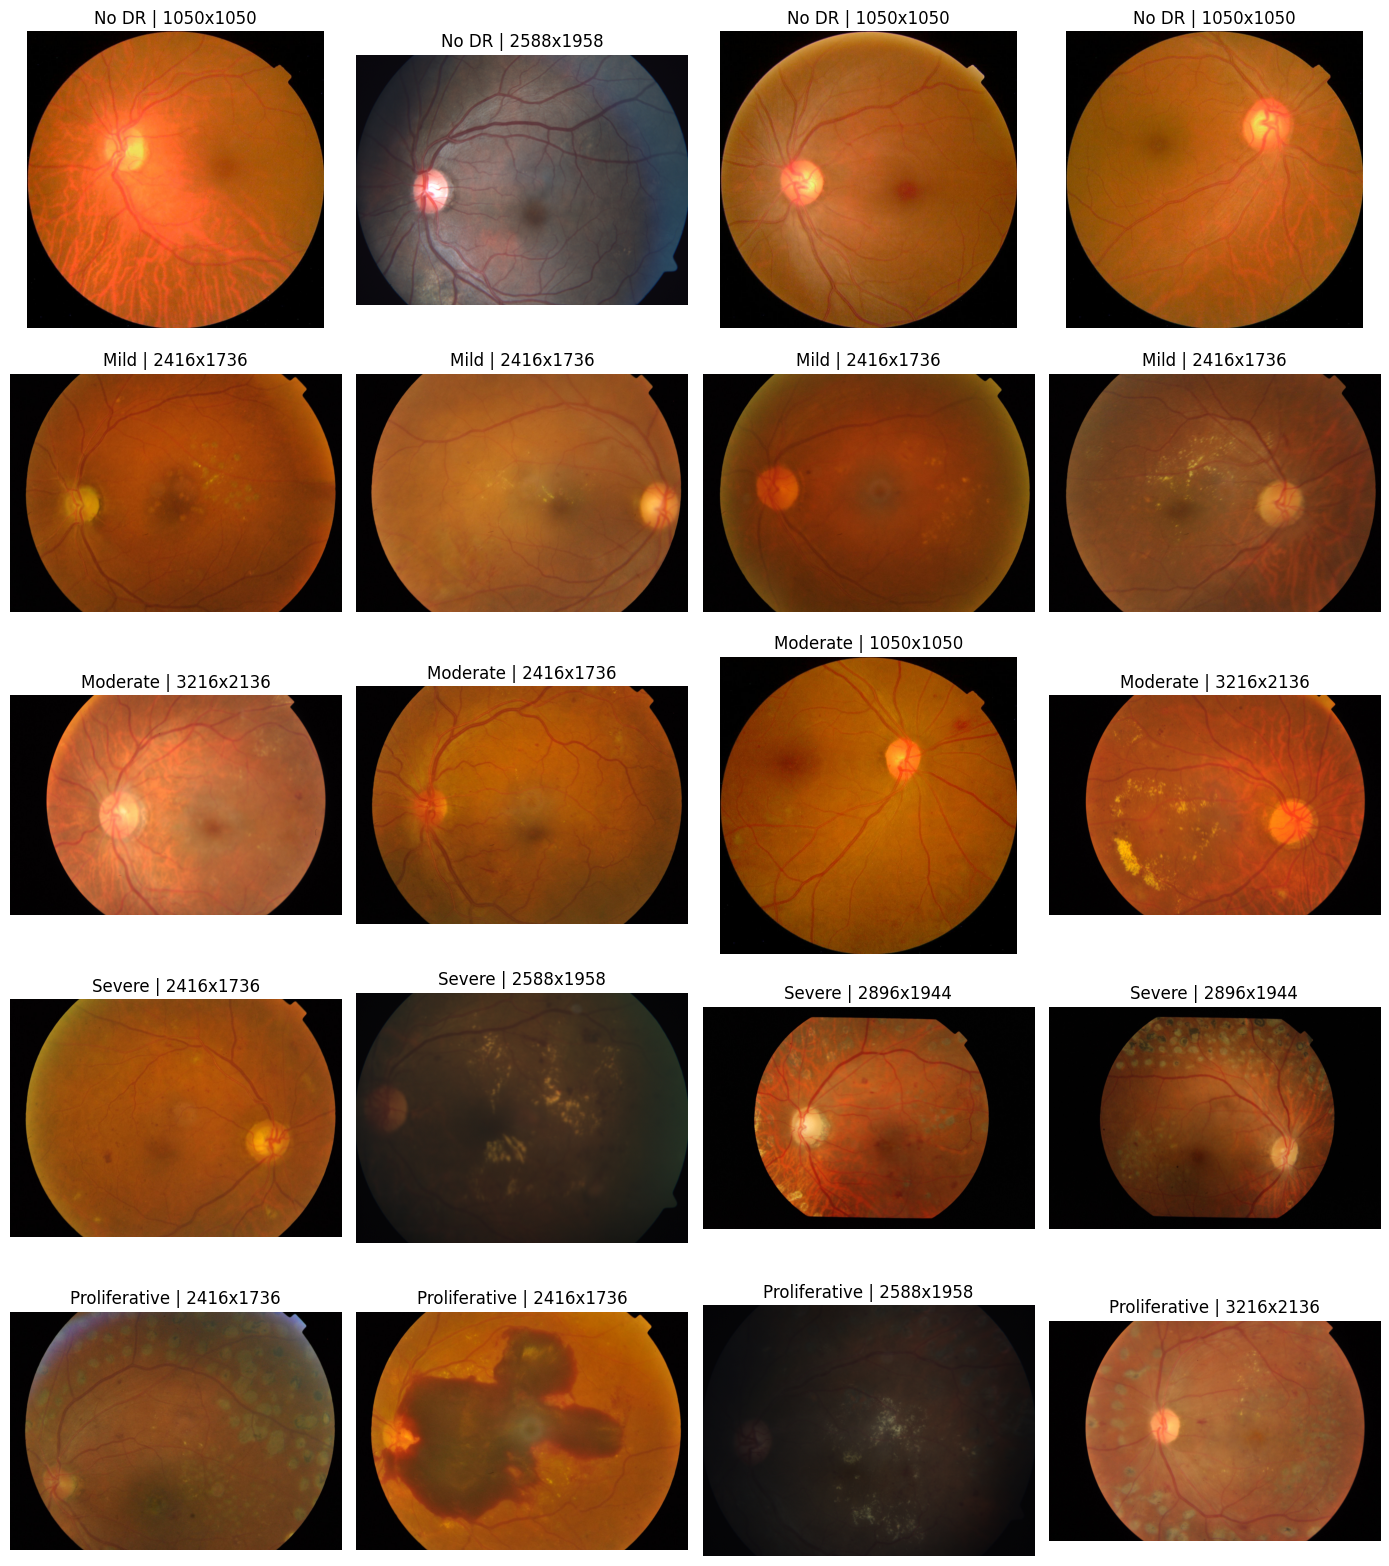

In [5]:
fig, axes = plt.subplots(5, 4, figsize=(14, 16))
for g in range(5):
    samples = df[df.diagnosis == g].sample(4, random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(f'{BASE}/train_images/{row.id_code}.png')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[g, j].imshow(img); axes[g, j].axis('off')
        axes[g, j].set_title(f'{labels[g]} | {img.shape[1]}x{img.shape[0]}')
plt.tight_layout(); plt.show()

In [6]:
from joblib import Parallel, delayed
IMG_SIZE = 256

def crop_black(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    rows = np.where(mask.any(1))[0]; cols = np.where(mask.any(0))[0]
    if len(rows) == 0 or len(cols) == 0: return img
    return img[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]

def pad_square(img):
    h, w = img.shape[:2]; s = max(h, w)
    out = np.zeros((s, s, 3), dtype=np.uint8)
    out[(s-h)//2:(s-h)//2+h, (s-w)//2:(s-w)//2+w] = img
    return out

def preprocess(path):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img = pad_square(crop_black(img))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0,0), IMG_SIZE/30), -4, 128)
    return img

In [7]:
paths = [f'{BASE}/train_images/{i}.png' for i in df.id_code]
X = np.array(Parallel(n_jobs=4)(delayed(preprocess)(p) for p in paths))
y = df.diagnosis.values
np.save('/kaggle/working/X_256.npy', X); np.save('/kaggle/working/y.npy', y)
print(X.shape, y.shape)

(3662, 256, 256, 3) (3662,)


In [8]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(y))
tr_idx, tmp_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
va_idx, te_idx = train_test_split(tmp_idx, test_size=0.5, stratify=y[tmp_idx], random_state=42)

for name, ix in [('train', tr_idx), ('val', va_idx), ('test', te_idx)]:
    print(name, len(ix), np.bincount(y[ix]))

train 2929 [1444  296  799  154  236]
val 366 [180  37 100  20  29]
test 367 [181  37 100  19  30]


In [9]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

train_tf = T.Compose([
    T.ToPILImage(), T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandomRotation(30), T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(), T.Normalize(MEAN, STD)])
eval_tf = T.Compose([T.ToPILImage(), T.ToTensor(), T.Normalize(MEAN, STD)])

class DRDataset(Dataset):
    def __init__(self, X, y, idx, tf): self.X, self.y, self.idx, self.tf = X, y, idx, tf
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        return self.tf(self.X[j]), int(self.y[j])

BS = 32
train_dl = DataLoader(DRDataset(X, y, tr_idx, train_tf), batch_size=BS, shuffle=True,  num_workers=2)
val_dl   = DataLoader(DRDataset(X, y, va_idx, eval_tf),  batch_size=BS, shuffle=False, num_workers=2)
test_dl  = DataLoader(DRDataset(X, y, te_idx, eval_tf),  batch_size=BS, shuffle=False, num_workers=2)

xb, yb = next(iter(train_dl)); print(xb.shape, yb[:8])

torch.Size([32, 3, 256, 256]) tensor([2, 2, 2, 0, 4, 2, 0, 0])


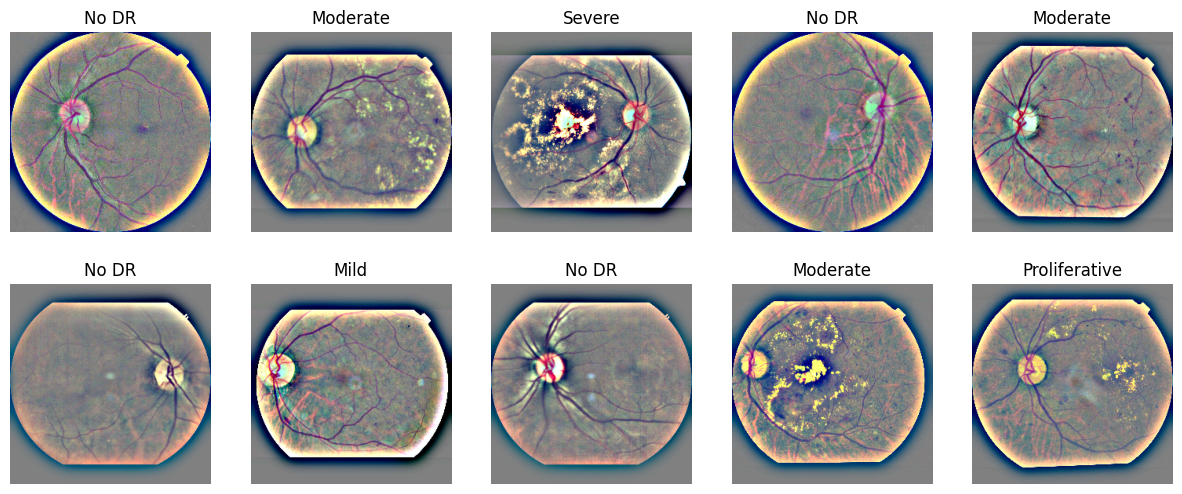

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, j in zip(axes.flat, tr_idx[:10]):
    ax.imshow(X[j]); ax.set_title(labels[y[j]]); ax.axis('off')
plt.show()

In [11]:
import time, torch.nn as nn
from sklearn.metrics import cohen_kappa_score, accuracy_score
!pip -q install timm
import timm

device = 'cuda'
cw = torch.tensor(len(tr_idx)/(5*np.bincount(y[tr_idx])), dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=cw)

def run_epoch(model, dl, opt=None, scaler=None):
    train = opt is not None
    model.train(train)
    losses, preds, gts = [], [], []
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            with torch.autocast('cuda', dtype=torch.float16):
                out = model(xb); loss = criterion(out, yb)
            if train:
                opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            losses.append(loss.item()); preds += out.argmax(1).cpu().tolist(); gts += yb.cpu().tolist()
    return np.mean(losses), accuracy_score(gts, preds), cohen_kappa_score(gts, preds, weights='quadratic')

def fit(model, name, epochs, lr):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda')
    hist, best = [], -1
    for ep in range(epochs):
        t0 = time.time()
        tl, ta, tk = run_epoch(model, train_dl, opt, scaler)
        vl, va, vk = run_epoch(model, val_dl)
        sched.step()
        hist.append((tl, vl, ta, va, tk, vk))
        if vk > best:
            best = vk; torch.save(model.state_dict(), f'/kaggle/working/{name}.pth')
        print(f'{name} ep{ep+1}/{epochs} | loss {tl:.3f}/{vl:.3f} | acc {ta:.3f}/{va:.3f} | QWK {tk:.3f}/{vk:.3f} | {time.time()-t0:.0f}s')
    return hist

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(i, o): return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2))
        self.f = nn.Sequential(blk(3,32), blk(32,64), blk(64,128), blk(128,256), nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.c = nn.Sequential(nn.Dropout(0.3), nn.Linear(256, 5))
    def forward(self, x): return self.c(self.f(x))

hist_cnn = fit(SimpleCNN(), 'baseline_cnn', 10, 1e-3)

baseline_cnn ep1/10 | loss 1.518/1.459 | acc 0.411/0.546 | QWK 0.300/0.438 | 11s
baseline_cnn ep2/10 | loss 1.369/2.147 | acc 0.535/0.093 | QWK 0.481/0.013 | 7s
baseline_cnn ep3/10 | loss 1.304/1.635 | acc 0.554/0.533 | QWK 0.559/0.308 | 7s
baseline_cnn ep4/10 | loss 1.233/1.266 | acc 0.568/0.484 | QWK 0.592/0.501 | 7s
baseline_cnn ep5/10 | loss 1.160/1.280 | acc 0.611/0.568 | QWK 0.660/0.648 | 7s
baseline_cnn ep6/10 | loss 1.131/1.167 | acc 0.608/0.664 | QWK 0.667/0.682 | 7s
baseline_cnn ep7/10 | loss 1.084/1.140 | acc 0.642/0.675 | QWK 0.705/0.709 | 7s
baseline_cnn ep8/10 | loss 1.069/1.182 | acc 0.658/0.604 | QWK 0.729/0.654 | 7s
baseline_cnn ep9/10 | loss 1.036/1.109 | acc 0.671/0.612 | QWK 0.743/0.690 | 7s
baseline_cnn ep10/10 | loss 1.006/1.103 | acc 0.674/0.642 | QWK 0.769/0.725 | 7s


In [13]:
effnet = timm.create_model('efficientnet_b0', pretrained=True, num_classes=5, drop_rate=0.3)
hist_eff = fit(effnet, 'effnet_b0', 15, 3e-4)

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

effnet_b0 ep1/15 | loss 2.008/1.386 | acc 0.554/0.727 | QWK 0.570/0.756 | 40s
effnet_b0 ep2/15 | loss 1.078/1.213 | acc 0.707/0.735 | QWK 0.799/0.824 | 12s
effnet_b0 ep3/15 | loss 0.948/1.018 | acc 0.746/0.743 | QWK 0.830/0.838 | 11s
effnet_b0 ep4/15 | loss 0.873/1.302 | acc 0.761/0.781 | QWK 0.850/0.831 | 12s
effnet_b0 ep5/15 | loss 0.750/1.544 | acc 0.786/0.770 | QWK 0.861/0.834 | 12s
effnet_b0 ep6/15 | loss 0.677/1.478 | acc 0.818/0.779 | QWK 0.888/0.840 | 12s
effnet_b0 ep7/15 | loss 0.571/1.356 | acc 0.832/0.792 | QWK 0.892/0.852 | 12s
effnet_b0 ep8/15 | loss 0.485/1.491 | acc 0.861/0.749 | QWK 0.913/0.821 | 12s
effnet_b0 ep9/15 | loss 0.459/1.442 | acc 0.870/0.779 | QWK 0.922/0.852 | 12s
effnet_b0 ep10/15 | loss 0.379/1.357 | acc 0.885/0.760 | QWK 0.931/0.847 | 12s
effnet_b0 ep11/15 | loss 0.340/1.370 | acc 0.900/0.765 | QWK 0.933/0.826 | 12s
effnet_b0 ep12/15 | loss 0.301/1.445 | acc 0.903/0.784 | QWK 0.942/0.842 | 12s
effnet_b0 ep13/15 | loss 0.281/1.426 | acc 0.918/0.784 | QWK 

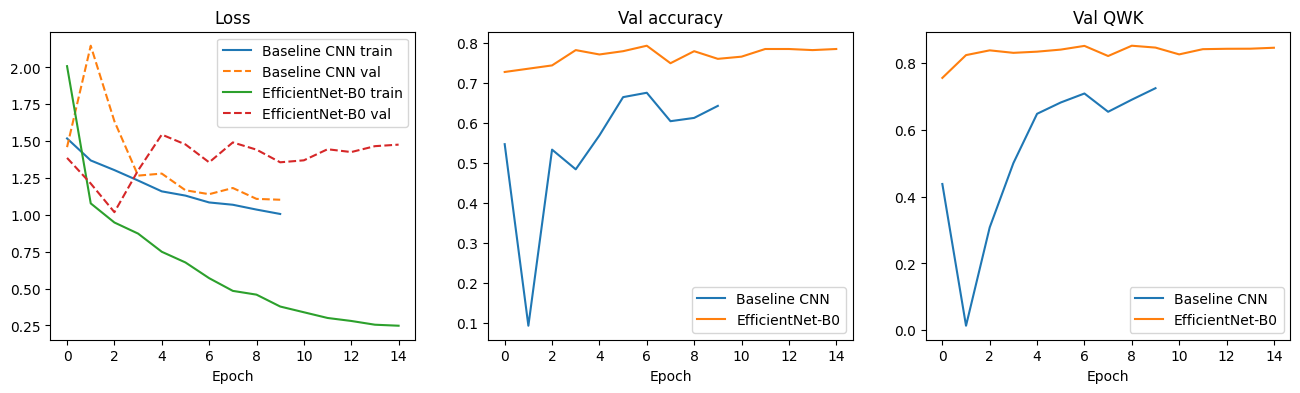

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for h, n in [(hist_cnn, 'Baseline CNN'), (hist_eff, 'EfficientNet-B0')]:
    h = np.array(h)
    ax[0].plot(h[:,0], label=f'{n} train'); ax[0].plot(h[:,1], '--', label=f'{n} val')
    ax[1].plot(h[:,3], label=n)
    ax[2].plot(h[:,5], label=n)
ax[0].set_title('Loss'); ax[1].set_title('Val accuracy'); ax[2].set_title('Val QWK')
for a in ax: a.set_xlabel('Epoch'); a.legend()
plt.show()

In [15]:
def get_preds(model, dl):
    model.eval(); probs, gts = [], []
    with torch.no_grad():
        for xb, yb in dl:
            with torch.autocast('cuda', dtype=torch.float16):
                out = model(xb.to(device))
            probs.append(torch.softmax(out.float(), 1).cpu().numpy()); gts += yb.tolist()
    return np.concatenate(probs), np.array(gts)

cnn = SimpleCNN().to(device); cnn.load_state_dict(torch.load('/kaggle/working/baseline_cnn.pth'))
eff = timm.create_model('efficientnet_b0', pretrained=False, num_classes=5, drop_rate=0.3).to(device)
eff.load_state_dict(torch.load('/kaggle/working/effnet_b0.pth'))

p_cnn, y_te = get_preds(cnn, test_dl)
p_eff, _ = get_preds(eff, test_dl)

for n, p in [('Baseline CNN', p_cnn), ('EfficientNet-B0', p_eff)]:
    pr = p.argmax(1)
    print(f'{n}: acc {accuracy_score(y_te, pr):.3f} | QWK {cohen_kappa_score(y_te, pr, weights="quadratic"):.3f}')

Baseline CNN: acc 0.676 | QWK 0.775
EfficientNet-B0: acc 0.817 | QWK 0.893


               precision    recall  f1-score   support

        No DR       0.98      0.97      0.98       181
         Mild       0.59      0.65      0.62        37
     Moderate       0.77      0.71      0.74       100
       Severe       0.43      0.47      0.45        19
Proliferative       0.61      0.67      0.63        30

     accuracy                           0.82       367
    macro avg       0.67      0.69      0.68       367
 weighted avg       0.82      0.82      0.82       367



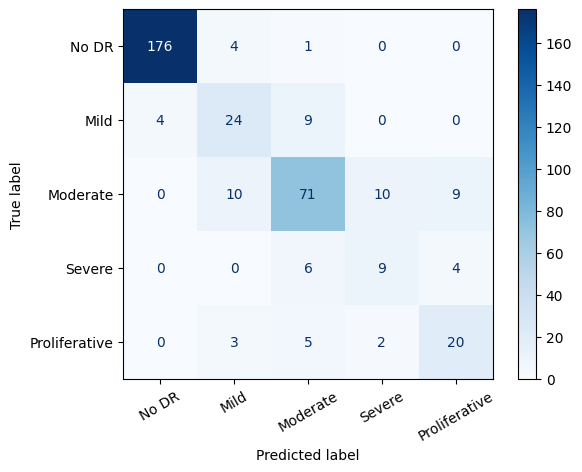

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

pr = p_eff.argmax(1)
print(classification_report(y_te, pr, target_names=list(labels.values())))
ConfusionMatrixDisplay(confusion_matrix(y_te, pr), display_labels=list(labels.values())).plot(cmap='Blues', xticks_rotation=30)
plt.show()

Sensitivity 0.919 | Specificity 0.959 | AUC 0.990


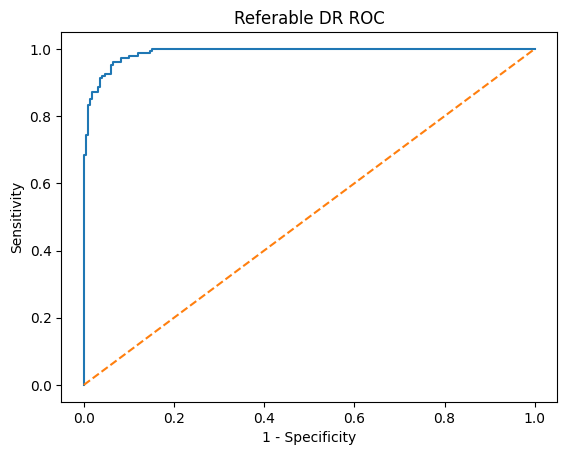

In [17]:
from sklearn.metrics import roc_auc_score, roc_curve

true_ref = (y_te >= 2).astype(int)
score_ref = p_eff[:, 2:].sum(1)
pred_ref = (score_ref >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(true_ref, pred_ref).ravel()
print(f'Sensitivity {tp/(tp+fn):.3f} | Specificity {tn/(tn+fp):.3f} | AUC {roc_auc_score(true_ref, score_ref):.3f}')

fpr, tpr, _ = roc_curve(true_ref, score_ref)
plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--')
plt.xlabel('1 - Specificity'); plt.ylabel('Sensitivity'); plt.title('Referable DR ROC')
plt.show()

In [18]:
eff.bn2._forward_hooks.clear()   # remove the old hook

class GradCAM:
    def __init__(self, model, layer):
        self.model, self.acts, self.grads = model, None, None
        layer.register_forward_hook(self._fwd)
    def _fwd(self, m, i, o):
        self.acts = o
        if o.requires_grad:                       # only when gradients are enabled
            o.register_hook(lambda g: setattr(self, 'grads', g))
    def __call__(self, x, cls=None):
        self.model.eval()
        out = self.model(x)
        cls = out.argmax(1).item() if cls is None else cls
        self.model.zero_grad(); out[0, cls].backward()
        w = self.grads.mean((2, 3), keepdim=True)
        cam = torch.relu((w * self.acts).sum(1)).squeeze().detach().cpu().numpy()
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, torch.softmax(out, 1).detach().cpu().numpy()[0], cls

gradcam = GradCAM(eff, eff.bn2)

def overlay(img, cam):
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img, 0.55, heat, 0.45, 0)

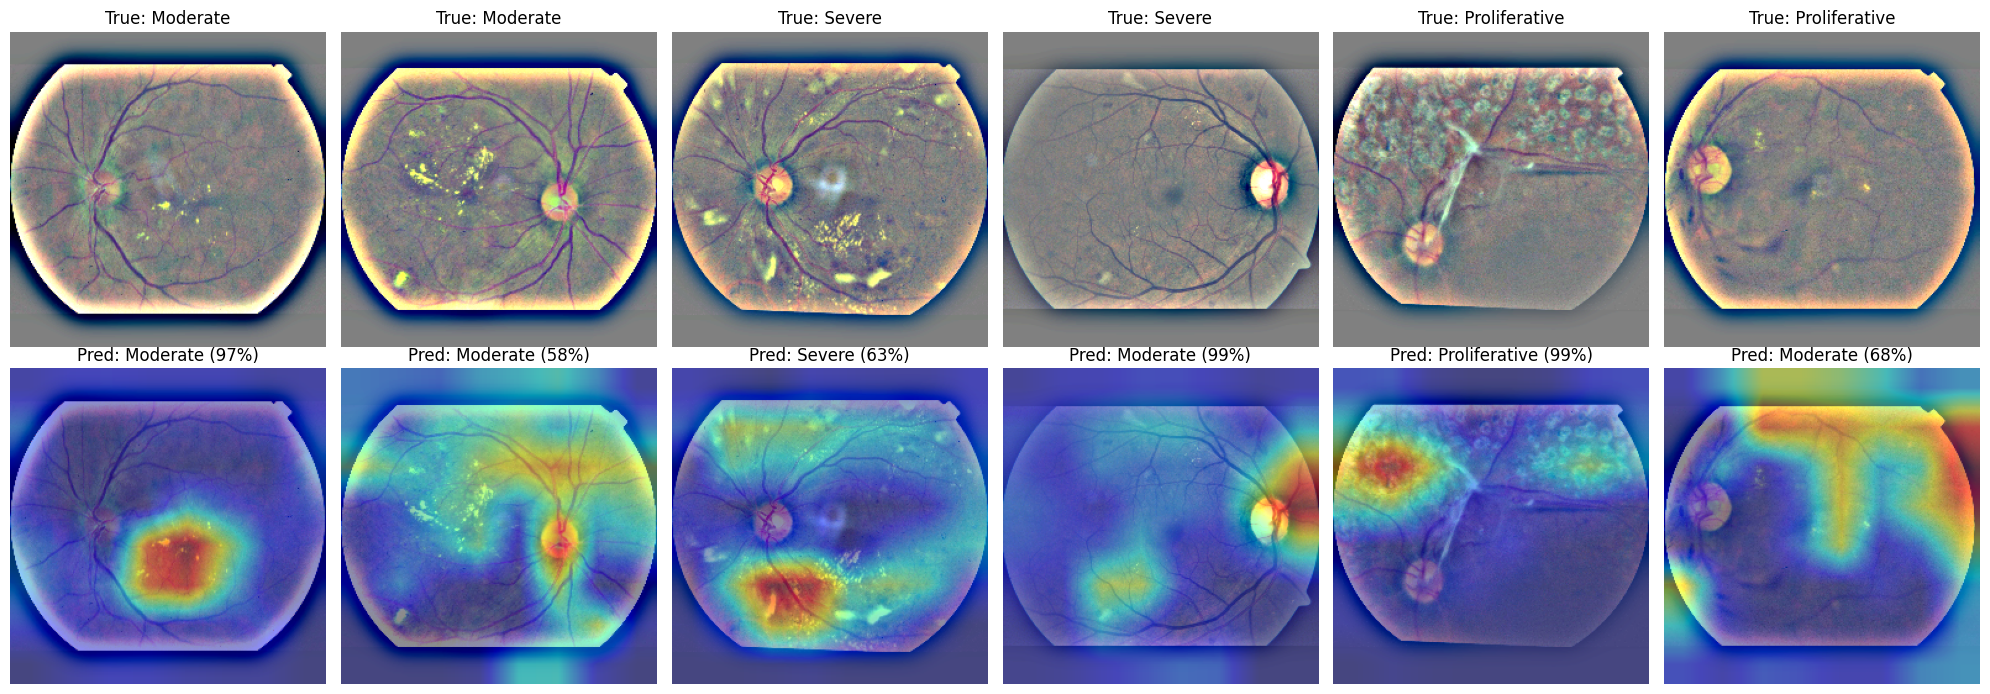

In [19]:
rng = np.random.RandomState(1)
picks = np.concatenate([rng.choice(te_idx[y[te_idx] == g], 2, replace=False) for g in [2, 3, 4]])

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for k, j in enumerate(picks):
    x = eval_tf(X[j]).unsqueeze(0).to(device)
    cam, prob, cls = gradcam(x)
    axes[0, k].imshow(X[j]); axes[0, k].axis('off')
    axes[0, k].set_title(f'True: {labels[y[j]]}')
    axes[1, k].imshow(overlay(X[j], cam)); axes[1, k].axis('off')
    axes[1, k].set_title(f'Pred: {labels[cls]} ({prob[cls]*100:.0f}%)')
plt.tight_layout(); plt.show()

In [20]:
p_val, y_val = get_preds(eff, val_dl)

def threshold_table(p, yt, thresholds):
    pr, conf = p.argmax(1), p.max(1)
    for t in thresholds:
        m = conf >= t
        acc = accuracy_score(yt[m], pr[m])
        rt, rp = yt[m] >= 2, p[m][:, 2:].sum(1) >= 0.5
        sens = (rt & rp).sum() / max(rt.sum(), 1)
        print(f'thr {t:.2f} | auto-decided {m.mean()*100:.0f}% | acc {acc:.3f} | referable sens {sens:.3f} | sent to doctor {(~m).sum()}')

threshold_table(p_val, y_val, [0.0, 0.4, 0.5, 0.6, 0.7, 0.8])

thr 0.00 | auto-decided 100% | acc 0.779 | referable sens 0.832 | sent to doctor 0
thr 0.40 | auto-decided 100% | acc 0.781 | referable sens 0.831 | sent to doctor 1
thr 0.50 | auto-decided 96% | acc 0.793 | referable sens 0.832 | sent to doctor 14
thr 0.60 | auto-decided 90% | acc 0.815 | referable sens 0.835 | sent to doctor 36
thr 0.70 | auto-decided 84% | acc 0.834 | referable sens 0.861 | sent to doctor 59
thr 0.80 | auto-decided 77% | acc 0.875 | referable sens 0.863 | sent to doctor 86


In [21]:
THR = 0.6   # change this to the value from the table that gives a good balance

print('--- TEST SET ---')
threshold_table(p_eff, y_te, [THR])

def triage(prob, thr=THR):
    cls, conf = int(prob.argmax()), float(prob.max())
    ref_score = float(prob[2:].sum())
    if conf < thr:
        return 'UNCERTAIN - please consult an eye doctor', cls, conf, ref_score
    if ref_score >= 0.5:
        return 'REFERABLE DR - refer to an eye specialist', cls, conf, ref_score
    return 'No referable DR detected - routine annual screening', cls, conf, ref_score

print(triage(p_eff[0]))

--- TEST SET ---
thr 0.60 | auto-decided 92% | acc 0.861 | referable sens 0.921 | sent to doctor 28
('No referable DR detected - routine annual screening', 0, 0.9988988637924194, 0.00010659432882675901)


In [22]:
import shutil
os.makedirs('/kaggle/working/samples', exist_ok=True)
for g in range(5):
    r = df.iloc[te_idx[y[te_idx] == g][0]]
    shutil.copy(f'{BASE}/train_images/{r.id_code}.png', f'/kaggle/working/samples/grade{g}_{r.id_code}.png')
print(os.listdir('/kaggle/working/samples'))
print(round(os.path.getsize('/kaggle/working/effnet_b0.pth')/1e6, 1), 'MB')

['grade0_3580a545016d.png', 'grade1_9ed666e982cd.png', 'grade4_3206171db5be.png', 'grade2_6531070bf03c.png', 'grade3_c76664770c07.png']
16.4 MB
